# SPARCS 2021 Knee Arthroplasty Business Case Analysis

This notebook analyzes the New York SPARCS 2021 inpatient discharge dataset to answer four business questions:

1. For knee arthroplasty patients, describe cost and length of stay by payer type.
2. What is the payer mix by hospital service area?
3. What factors influence cost and what factors influence length of stay?
4. Why are these questions important for business strategy?

The analysis uses descriptive statistics and regression modeling. No machine learning methods are used.

## Methodology

This analysis uses the 2021 SPARCS inpatient discharge dataset from the New York State Department of Health. The goal was to evaluate cost and utilization patterns for knee arthroplasty hospitalizations and identify factors associated with variation in total cost and length of stay.

### Data Preparation

The dataset was imported directly from the Health Data NY API. Several preparation steps were performed before analysis:

- Records associated with knee arthroplasty procedures were identified using **CCSR Procedure Description** and **APR DRG Description** fields containing terms such as *knee*, *arthroplasty*, or *replacement*.
- Observations missing key variables such as payer type, cost, length of stay, or hospital service area were removed.
- Length of stay values were converted to numeric values and cleaned where the dataset used top-coded values such as "120+".
- Total cost values were converted to numeric format.
- Extreme outliers were trimmed by removing observations above the 99th percentile for cost and length of stay to reduce the influence of unusually large values.

These steps produced a cleaned analytic dataset focused on knee arthroplasty hospitalizations.

### Descriptive Analysis

Descriptive statistics were used to answer the first two business questions.

- Average and median **total cost** and **length of stay** were calculated by **payer type**.
- **Payer mix by hospital service area** was calculated as the percentage of knee arthroplasty discharges associated with each payer category.
- Visualizations were created to illustrate differences in cost, length of stay, and payer distribution across regions.

### Regression Analysis

Ordinary least squares (OLS) regression models were used to identify factors associated with variation in cost and length of stay.

Two models were estimated:

- **Log-transformed total cost**
- **Log-transformed length of stay**

The following explanatory variables were included in the models:

- payer type  
- age group  
- gender  
- race  

The dependent variables were log-transformed because healthcare cost and utilization data are typically right-skewed. Log transformation reduces the influence of extreme values and produces more stable model estimates.

Regression analysis allows the relationship between each factor and the outcome to be evaluated while controlling for other variables in the model.

### Interpretation

The regression results were used to determine whether the same factors influence both cost and length of stay. By comparing coefficients and statistical significance across the two models, the analysis identifies which factors are shared drivers and which influence only one of the outcomes.

Source: https://www.mayoclinic.org/tests-procedures/knee-replacement/about/pac-20385276

In [ ]:
import pandas as pd

# SPARCS 2021 dataset ID from the PowerPoint link
url = "https://health.data.ny.gov/resource/tg3i-cinn.csv?$limit=5000000"

df = pd.read_csv(url, low_memory=False)

print(df.shape)
df.head()

(2135260, 33)


,hospital_service_area,hospital_county,operating_certificate_number,permanent_facility_id,facility_name,age_group,zip_code_3_digits,gender,race,ethnicity,...,apr_severity_of_illness,apr_risk_of_mortality,apr_medical_surgical,payment_typology_1,payment_typology_2,payment_typology_3,birth_weight,emergency_department_indicator,total_charges,total_costs
0,New York City,Bronx,7000006.0,1169.0,Montefiore Medical Center - Henry & Lucy Moses...,70 or Older,104,M,Other Race,Spanish/Hispanic,...,Major,Extreme,Medical,Medicare,Medicaid,NaN,NaN,Y,320922.43,60241.34
1,New York City,Bronx,7000006.0,1169.0,Montefiore Medical Center - Henry & Lucy Moses...,50 to 69,104,F,White,Not Span/Hispanic,...,Moderate,Minor,Medical,Private Health Insurance,NaN,NaN,NaN,Y,61665.22,9180.69
2,New York City,Bronx,7000006.0,1168.0,Montefiore Medical Center-Wakefield Hospital,18 to 29,104,F,Other Race,Spanish/Hispanic,...,Minor,Minor,Surgical,Medicaid,NaN,NaN,NaN,N,42705.34,11366.50
3,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,70 or Older,104,M,Other Race,Spanish/Hispanic,...,Major,Major,Medical,Medicare,Medicaid,NaN,NaN,Y,72700.17,12111.75
4,New York City,Bronx,7000006.0,1169.0,Montefiore Medical Center - Henry & Lucy Moses...,50 to 69,104,F,Black/African American,Not Span/Hispanic,...,Moderate,Minor,Medical,Medicare,Medicaid,NaN,NaN,Y,55562.51,8339.72


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# Direct SPARCS 2021 dataset link
url = "https://health.data.ny.gov/resource/tg3i-cinn.csv?$limit=5000000"

df = pd.read_csv(url, low_memory=False)

print("Shape:", df.shape)
print("\nColumns:")
for c in df.columns:
    print(c)

Shape: (2135260, 33)

Columns:
hospital_service_area
hospital_county
operating_certificate_number
permanent_facility_id
facility_name
age_group
zip_code_3_digits
gender
race
ethnicity
length_of_stay
type_of_admission
patient_disposition
discharge_year
ccsr_diagnosis_code
ccsr_diagnosis_description
ccsr_procedure_code
ccsr_procedure_description
apr_drg_code
apr_drg_description
apr_mdc_code
apr_mdc_description
apr_severity_of_illness_code
apr_severity_of_illness
apr_risk_of_mortality
apr_medical_surgical
payment_typology_1
payment_typology_2
payment_typology_3
birth_weight
emergency_department_indicator
total_charges
total_costs


In [ ]:
print(df.columns.tolist())

['hospital_service_area', 'hospital_county', 'operating_certificate_number', 'permanent_facility_id', 'facility_name', 'age_group', 'zip_code_3_digits', 'gender', 'race', 'ethnicity', 'length_of_stay', 'type_of_admission', 'patient_disposition', 'discharge_year', 'ccsr_diagnosis_code', 'ccsr_diagnosis_description', 'ccsr_procedure_code', 'ccsr_procedure_description', 'apr_drg_code', 'apr_drg_description', 'apr_mdc_code', 'apr_mdc_description', 'apr_severity_of_illness_code', 'apr_severity_of_illness', 'apr_risk_of_mortality', 'apr_medical_surgical', 'payment_typology_1', 'payment_typology_2', 'payment_typology_3', 'birth_weight', 'emergency_department_indicator', 'total_charges', 'total_costs']


#Diagnostic: investigate knee procedure descriptions

This step supports the assignment requirement to **investigate how knee arthroplasty patients can be identified.**

In [ ]:
print("Knee-related values in ccsr_procedure_description:")

display(
    df[df["ccsr_procedure_description"].astype(str).str.contains("knee", case=False, na=False)]
    ["ccsr_procedure_description"]
    .value_counts()
    .head(20)
)

print("\nKnee-related values in apr_drg_description:")

display(
    df[df["apr_drg_description"].astype(str).str.contains("knee", case=False, na=False)]
    ["apr_drg_description"]
    .value_counts()
    .head(20)
)

Knee-related values in ccsr_procedure_description:


,count
ccsr_procedure_description,
KNEE ARTHROPLASTY,22214
ARTHROPLASTY OF OTHER JOINT (EXCLUDING KNEE AND HIP),4022
BELOW KNEE AMPUTATION,1604
ABOVE KNEE AND OTHER PROXIMAL LOWER EXTREMITY AMPUTATION,1000



Knee-related values in apr_drg_description:


,count
apr_drg_description,
ELECTIVE KNEE JOINT REPLACEMENT,19711
KNEE AND LOWER LEG PROCEDURES EXCEPT FOOT,8547
NON-ELECTIVE OR COMPLEX KNEE JOINT REPLACEMENT,2243


## Identifying Knee Arthroplasty Patients

To identify knee arthroplasty patients in the SPARCS dataset, the analysis uses one descriptive variables:

• **CCSR Procedure Description**  

The variable CCSR (Clinical Classification Software Refined) Procedure Description provides the most accurate clinical groupings of procedures and hospitalizations, with the field value of "KNEE ARTHOPLASTY".

DRG Codes identifying knee arthoplasty are MS-DRG 469 (with MCC) and 470 (without MCC). These codes are too broad and refer to "Major Joint Replacement/Reattachment of the Lower Extremity" with MCC being Major Complexity/Comorbidity.

APR (All Patient-Refined) DRG Descriptions had values in its field which focused on knee replacements, however, though all of these fields mapped to "KNEE ARTHOPLASTY" under the ccsr procedure description, all "KNEE ARTHOPLASTY" values under the CCSR Procedure Description did *not* map back to fields which mentioned knee procedures.

For example: for a CCSR Procedure description of "KNEE ARTHOPLASTY", one value for the APR DRG Description field was "OTHER MUSCULOSKELETAL SYSTEM AND CONNECTIVE TISSUE PROCEDURE".



This approach is appropriate for a de-identified administrative dataset where detailed procedure codes may not be the easiest variables to interpret.

**Source:** https://www.cms.gov/priorities/innovation/innovation-models/cjr

#Create Knee Arthoplasty Cohort

In [ ]:
knee_mask = df["ccsr_procedure_description"].astype(str).str.strip() == "KNEE ARTHROPLASTY"

knee = df[knee_mask].copy()

print("Knee arthroplasty cohort size:", knee.shape)

Knee arthroplasty cohort size: (22214, 33)


#Prepare Analytic Dataset

In [ ]:
hsa_col = "hospital_service_area"
los_col = "length_of_stay"
cost_col = "total_costs"
payer_col = "payment_typology_1"

analytic = knee.copy()

analytic[cost_col] = pd.to_numeric(analytic[cost_col], errors="coerce")

analytic[los_col] = (
    analytic[los_col]
    .astype(str)
    .str.replace("+", "", regex=False)
)

analytic[los_col] = pd.to_numeric(analytic[los_col], errors="coerce")

analytic = analytic.dropna(subset=[payer_col, cost_col, los_col, hsa_col])
analytic = analytic[(analytic[cost_col] > 0) & (analytic[los_col] > 0)].copy()

print("Clean analytic dataset:", analytic.shape)

Clean analytic dataset: (22199, 33)


#Remove Extreme Outliers

In [ ]:
cost_upper = analytic[cost_col].quantile(0.99)
los_upper = analytic[los_col].quantile(0.99)

analytic_trim = analytic[
    (analytic[cost_col] <= cost_upper) &
    (analytic[los_col] <= los_upper)
].copy()

print("Trimmed dataset:", analytic_trim.shape)

Trimmed dataset: (21869, 33)


#Question 1: Cost and LOS by Payer

In [ ]:
q1 = (
    analytic_trim
    .groupby(payer_col)
    .agg(
        Cases=(cost_col, "count"),
        Average_Cost=(cost_col, "mean"),
        #median_cost=(cost_col, "median"),
        Average_LOS=(los_col, "mean"),
        #median_los=(los_col, "median")
    )
    .sort_values("Average_Cost", ascending=False)
)

q1.round(2)

,Cases,Average_Cost,Average_LOS
payment_typology_1,,,
"Managed Care, Unspecified",138,29542.68,2.42
Self-Pay,124,28844.94,2.31
Medicaid,1988,27081.15,2.58
Department of Corrections,3,26844.67,3.00
Private Health Insurance,3236,26109.88,2.13
Medicare,12800,25395.03,2.53
Blue Cross/Blue Shield,2522,23385.39,2.06
Miscellaneous/Other,976,22521.03,2.27
Federal/State/Local/VA,82,20437.65,2.43


| Payer Type                   | Cases  | Avg Cost per Case ($USD) | Avg Length of Stay (Days) |
| ---------------------------- | ------ | ------------------------ | ------------------------- |
| Medicare                     | 12,800 | 25,395                   | 2.5                       |
| Private Health Insurance     | 3,236  | 26,110                   | 2.1                       |
| Blue Cross / Blue Shield     | 2,522  | 23,385                   | 2.1                       |
| Medicaid                     | 1,988  | 27,081                   | 2.6                       |
| Miscellaneous / Other        | 976    | 22,521                   | 2.3                       |
| Managed Care (Unspecified)   | 138    | 29,543                   | 2.4                       |
| Self-Pay                     | 124    | 28,845                   | 2.3                       |
| Federal / State / Local / VA | 82     | 20,438                   | 2.4                       |
| Department of Corrections    | 3      | 26,845                   | 3.0                       |


#Question 1 Visual

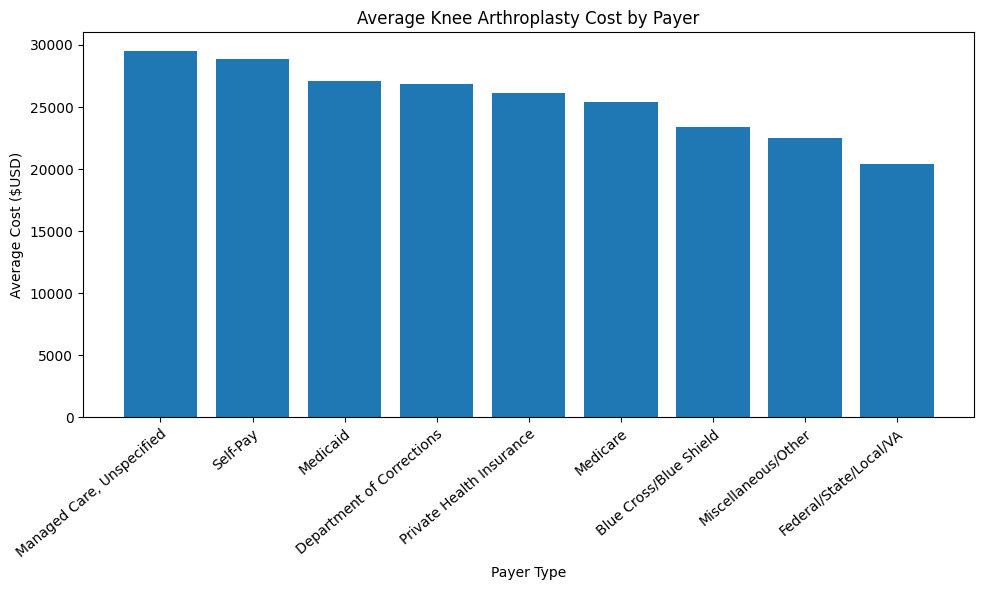

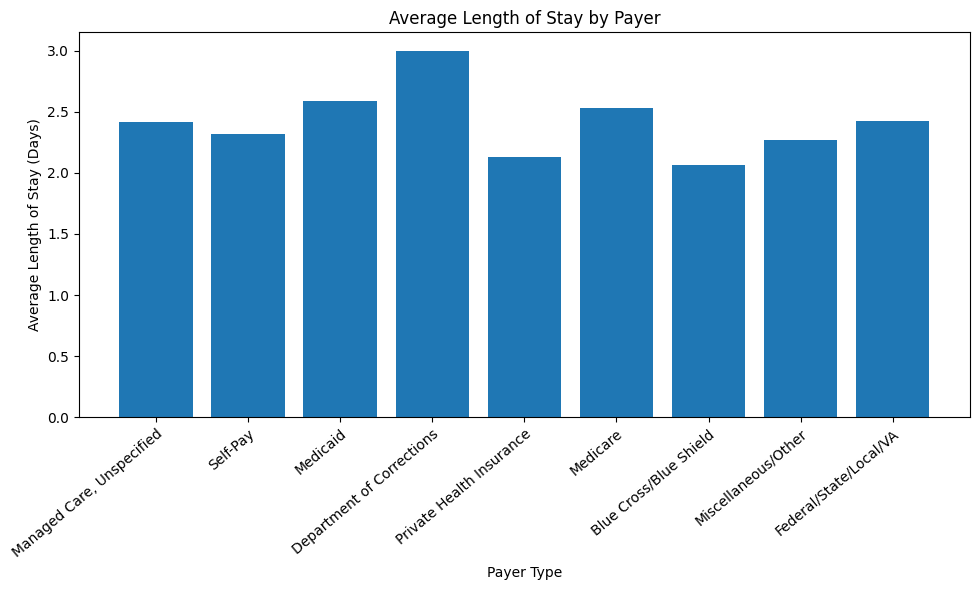

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(q1.index, q1["Average_Cost"])
plt.xticks(rotation=45)
plt.xlabel("Payer Type")
plt.ylabel("Average Cost ($USD)")
plt.title("Average Knee Arthroplasty Cost by Payer")
plt.xticks(rotation=40, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
bars = plt.bar(q1.index, q1["Average_LOS"])
plt.title("Average Length of Stay by Payer")
plt.xlabel("Payer Type")
plt.ylabel("Average Length of Stay (Days)")
plt.xticks(rotation=40, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

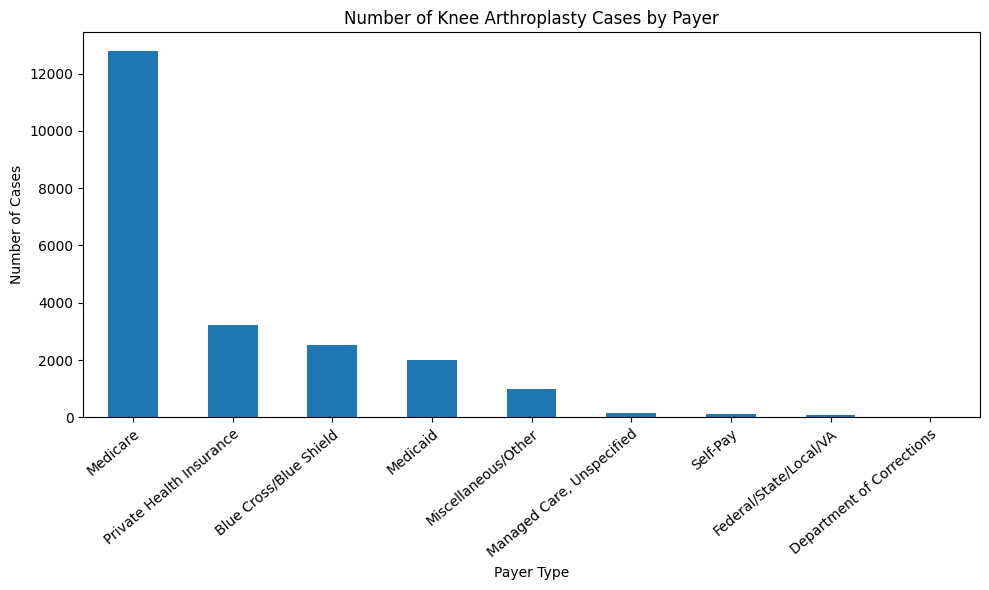

In [ ]:
cases_by_payer = (
    analytic_trim
    .groupby("payment_typology_1")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
cases_by_payer.plot(kind="bar")

plt.title("Number of Knee Arthroplasty Cases by Payer")
plt.xlabel("Payer Type")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.xticks(rotation=40, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

#Question 2: Payer Mix by Hospital Service Area

In [ ]:
cases_by_hsa = (
    analytic_trim
    .groupby("hospital_service_area")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="cases")
)

cases_by_hsa

,hospital_service_area,cases
0,New York City,11378
1,Long Island,4747
2,Hudson Valley,1631
3,Finger Lakes,1335
4,Central NY,1052
5,Capital/Adirond,952
6,Western NY,552
7,Southern Tier,222


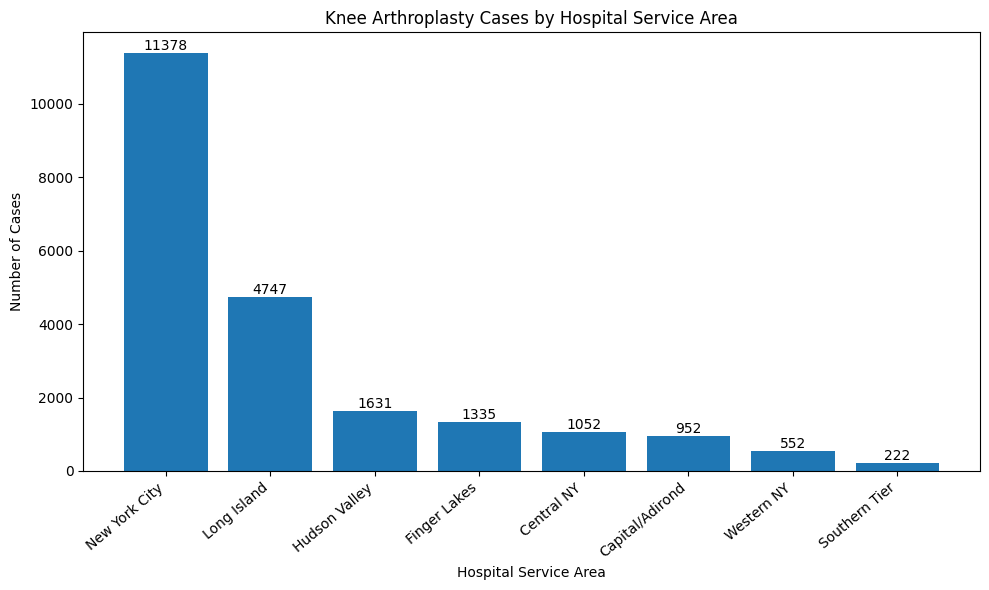

In [ ]:
cases_by_hsa = (
    analytic_trim
    .groupby("hospital_service_area")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
bars = plt.bar(cases_by_hsa.index, cases_by_hsa.values)

plt.title("Knee Arthroplasty Cases by Hospital Service Area")
plt.xlabel("Hospital Service Area")
plt.ylabel("Number of Cases")

plt.xticks(rotation=40, ha="right")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, int(y),
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

#Question 2: Cases by Hospital Service Area Tables

In [ ]:
cases_by_hsa = (
    analytic_trim
    .groupby(hsa_col)
    .size()
    .reset_index(name="cases")
    .sort_values("cases", ascending=False)
)

cases_by_hsa["percent"] = (
    cases_by_hsa["cases"] /
    cases_by_hsa["cases"].sum()
) * 100

cases_by_hsa = cases_by_hsa.rename(columns={
    hsa_col: "Hospital Service Area",
    "cases": "Cases",
    "percent": "Percent"
})

# remove index when displaying
display(cases_by_hsa.round(2).style.hide(axis="index"))

Hospital Service Area,Cases,Percent
New York City,11378,52.030000
Long Island,4747,21.710000
Hudson Valley,1631,7.460000
Finger Lakes,1335,6.100000
Central NY,1052,4.810000
Capital/Adirond,952,4.350000
Western NY,552,2.520000
Southern Tier,222,1.020000


In [ ]:
payer_hsa = (
    analytic_trim
    .groupby([hsa_col, payer_col])
    .size()
    .reset_index(name="cases")
)

# remove Medicare since it is already shown elsewhere
payer_hsa = payer_hsa[payer_hsa[payer_col] != "Medicare"]

# calculate percent within each service area
payer_hsa["percent"] = (
    payer_hsa["cases"] /
    payer_hsa.groupby(hsa_col)["cases"].transform("sum")
) * 100

# sort and keep top 2 remaining payers (2nd and 3rd overall)
top_non_medicare = (
    payer_hsa
    .sort_values([hsa_col, "cases"], ascending=[True, False])
    .groupby(hsa_col)
    .head(2)
)

# rename columns for presentation
top_non_medicare = top_non_medicare.rename(columns={
    hsa_col: "Hospital Service Area",
    payer_col: "Non-Medicare Payer Types",
    "cases": "Cases",
    "percent": "Percent"
})

display(top_non_medicare.round(2).style.hide(axis="index"))

Hospital Service Area,Non-Medicare Payer Types,Cases,Percent
Capital/Adirond,Blue Cross/Blue Shield,126,36.840000
Capital/Adirond,Private Health Insurance,100,29.240000
Central NY,Blue Cross/Blue Shield,209,46.760000
Central NY,Private Health Insurance,76,17.000000
Finger Lakes,Blue Cross/Blue Shield,243,50.100000
Finger Lakes,Medicaid,97,20.000000
Hudson Valley,Private Health Insurance,235,37.840000
Hudson Valley,Blue Cross/Blue Shield,160,25.760000
Long Island,Blue Cross/Blue Shield,636,31.930000
Long Island,Private Health Insurance,595,29.870000


In [ ]:
payer_hsa = (
    analytic_trim
    .groupby([hsa_col, payer_col])
    .size()
    .reset_index(name="cases")
)

# Remove Medicare
payer_hsa = payer_hsa[payer_hsa[payer_col] != "Medicare"].copy()

# Percent within each service area
payer_hsa["percent"] = (
    payer_hsa["cases"] /
    payer_hsa.groupby(hsa_col)["cases"].transform("sum")
) * 100

# Sort within each service area by cases descending
top_non_medicare = (
    payer_hsa
    .sort_values([hsa_col, "cases"], ascending=[True, False])
    .groupby(hsa_col)
    .head(2)
    .copy()
)

# Rank within each service area
top_non_medicare["Rank"] = (
    top_non_medicare
    .groupby(hsa_col)
    .cumcount() + 1
)

# Rename columns for presentation
top_non_medicare = top_non_medicare.rename(columns={
    hsa_col: "Hospital Service Area",
    payer_col: "Non-Medicare Payer Types",
    "cases": "Cases",
    "percent": "Percent"
})

top_non_medicare = top_non_medicare.reset_index(drop=True)

display(top_non_medicare.round(2).style.hide(axis="index"))

Hospital Service Area,Non-Medicare Payer Types,Cases,Percent,Rank
Capital/Adirond,Blue Cross/Blue Shield,126,36.840000,1
Capital/Adirond,Private Health Insurance,100,29.240000,2
Central NY,Blue Cross/Blue Shield,209,46.760000,1
Central NY,Private Health Insurance,76,17.000000,2
Finger Lakes,Blue Cross/Blue Shield,243,50.100000,1
Finger Lakes,Medicaid,97,20.000000,2
Hudson Valley,Private Health Insurance,235,37.840000,1
Hudson Valley,Blue Cross/Blue Shield,160,25.760000,2
Long Island,Blue Cross/Blue Shield,636,31.930000,1
Long Island,Private Health Insurance,595,29.870000,2


In [ ]:
def bold_second_highest(row):
    if row["Rank"] == 1:
        return ["font-weight: bold;"] * len(row)
    return [""] * len(row)

display(
    top_non_medicare.round(2)
    .style
    .apply(bold_second_highest, axis=1)
    .hide(axis="index")
)

Hospital Service Area,Non-Medicare Payer Types,Cases,Percent,Rank
Capital/Adirond,Blue Cross/Blue Shield,126,36.840000,1
Capital/Adirond,Private Health Insurance,100,29.240000,2
Central NY,Blue Cross/Blue Shield,209,46.760000,1
Central NY,Private Health Insurance,76,17.000000,2
Finger Lakes,Blue Cross/Blue Shield,243,50.100000,1
Finger Lakes,Medicaid,97,20.000000,2
Hudson Valley,Private Health Insurance,235,37.840000,1
Hudson Valley,Blue Cross/Blue Shield,160,25.760000,2
Long Island,Blue Cross/Blue Shield,636,31.930000,1
Long Island,Private Health Insurance,595,29.870000,2


In [ ]:
def bold_third_highest(row):
    if row["Rank"] == 2:
        return ["font-weight: bold;"] * len(row)
    return [""] * len(row)

display(
    top_non_medicare.round(2)
    .style
    .apply(bold_third_highest, axis=1)
    .hide(axis="index")
)

Hospital Service Area,Non-Medicare Payer Types,Cases,Percent,Rank
Capital/Adirond,Blue Cross/Blue Shield,126,36.840000,1
Capital/Adirond,Private Health Insurance,100,29.240000,2
Central NY,Blue Cross/Blue Shield,209,46.760000,1
Central NY,Private Health Insurance,76,17.000000,2
Finger Lakes,Blue Cross/Blue Shield,243,50.100000,1
Finger Lakes,Medicaid,97,20.000000,2
Hudson Valley,Private Health Insurance,235,37.840000,1
Hudson Valley,Blue Cross/Blue Shield,160,25.760000,2
Long Island,Blue Cross/Blue Shield,636,31.930000,1
Long Island,Private Health Insurance,595,29.870000,2


#Question 2 Visual

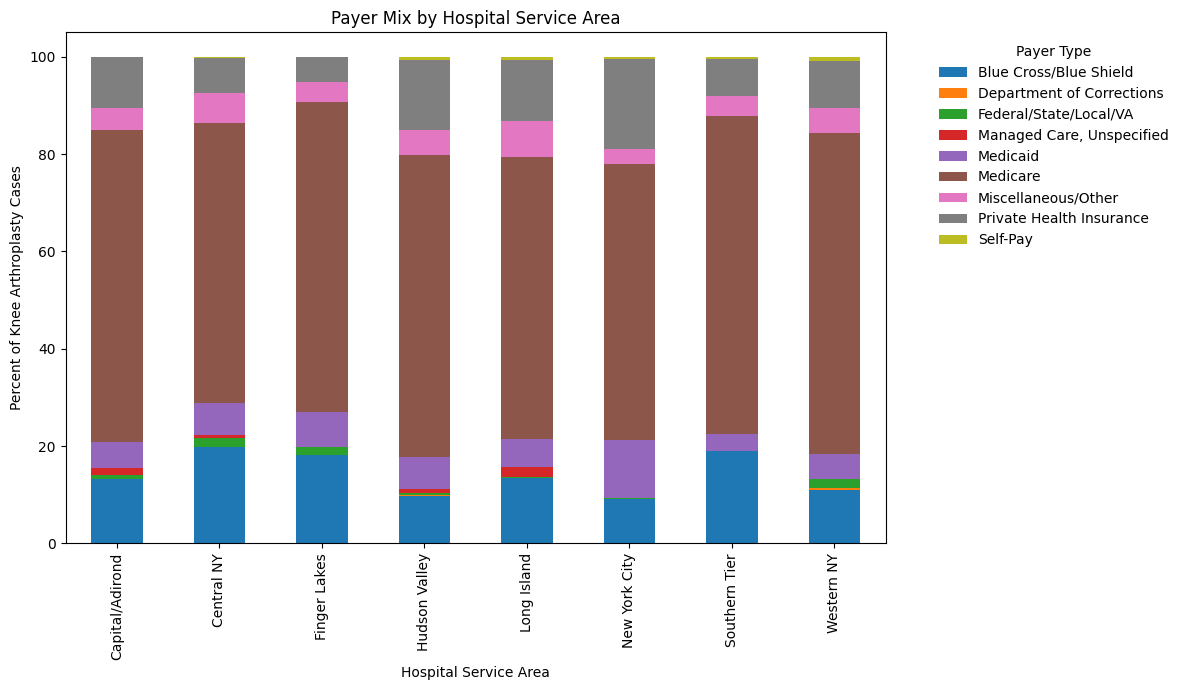

In [ ]:
fig, ax = plt.subplots(figsize=(12,7))

pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_ylabel("Percent of Knee Arthroplasty Cases")
ax.set_xlabel("Hospital Service Area")
ax.set_title("Payer Mix by Hospital Service Area")

ax.legend(
    title="Payer Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

#Question 3 Part 1: Regression to Determine Factors Influencing Cost

In [ ]:
model_df = analytic_trim.copy()

model_df["log_cost"] = np.log(model_df[cost_col])
model_df["log_los"] = np.log(model_df[los_col])

cost_model = smf.ols(
    "log_cost ~ C(payment_typology_1) + C(age_group) + C(gender) + C(race)",
    data=model_df
).fit()

print(cost_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_cost   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     37.88
Date:                Sun, 08 Mar 2026   Prob (F-statistic):          5.90e-117
Time:                        22:14:18   Log-Likelihood:                -16622.
No. Observations:               21869   AIC:                         3.328e+04
Df Residuals:                   21852   BIC:                         3.341e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

#Question 3 Part 2: Regression to Determine Factors Influencing LOS

In [ ]:
los_model = smf.ols(
    "log_los ~ C(payment_typology_1) + C(age_group) + C(gender) + C(race)",
    data=model_df
).fit()

print(los_model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_los   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     42.80
Date:                Sun, 08 Mar 2026   Prob (F-statistic):          3.41e-133
Time:                        22:14:21   Log-Likelihood:                -20638.
No. Observations:               21869   AIC:                         4.131e+04
Df Residuals:                   21852   BIC:                         4.145e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

| Metric      | Full Name               | Behavior                                            |
| ----------- | ----------------------- | --------------------------------------------------- |
| R²          | R-squared               | Percent of outcome variation explained by the model |
| Adjusted R² | Adjusted R-squared      | R² adjusted for number of predictors in the model   |
| RMSE        | Root Mean Squared Error | Penalizes large prediction errors strongly          |
| MAE         | Mean Absolute Error     | Treats all prediction errors equally                |


In [ ]:
import pandas as pd
import numpy as np

cost_rmse = np.sqrt(np.mean(cost_model.resid**2))
cost_mae = np.mean(np.abs(cost_model.resid))

los_rmse = np.sqrt(np.mean(los_model.resid**2))
los_mae = np.mean(np.abs(los_model.resid))

metrics_table = pd.DataFrame({
    "Model Evaluation Metric": [
        "R² (Explained Variation)",
        "Adjusted R²",
        "RMSE (Prediction Error)",
        "MAE (Average Error)"
    ],
    "Cost Model": [
        cost_model.rsquared,
        cost_model.rsquared_adj,
        cost_rmse,
        cost_mae
    ],
    "Length of Stay Model": [
        los_model.rsquared,
        los_model.rsquared_adj,
        los_rmse,
        los_mae
    ]
})

# Format numbers cleanly
metrics_table["Cost Model"] = metrics_table["Cost Model"].map(lambda x: f"{x:.3g}")
metrics_table["Length of Stay Model"] = metrics_table["Length of Stay Model"].map(lambda x: f"{x:.3g}")

display(
    metrics_table
    .style
    .set_table_styles([
        {"selector": "th", "props": [("font-weight", "bold"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]}
    ])
    .hide(axis="index")
)

Model Evaluation Metric,Cost Model,Length of Stay Model
R² (Explained Variation),0.027,0.0304
Adjusted R²,0.0263,0.0297
RMSE (Prediction Error),0.517,0.622
MAE (Average Error),0.413,0.51


#Question 3 Visuals for Regression

In [ ]:
import pandas as pd
import numpy as np

metrics = pd.DataFrame({
    "Metric": [
        "R-squared",
        "Adjusted R-squared",
        "AIC",
        "BIC",
        "RMSE",
        "MAE"
    ],
    "Cost Model": [
        cost_model.rsquared,
        cost_model.rsquared_adj,
        cost_model.aic,
        cost_model.bic,
        np.sqrt(np.mean(cost_model.resid**2)),
        np.mean(np.abs(cost_model.resid))
    ],
    "LOS Model": [
        los_model.rsquared,
        los_model.rsquared_adj,
        los_model.aic,
        los_model.bic,
        np.sqrt(np.mean(los_model.resid**2)),
        np.mean(np.abs(los_model.resid))
    ]
})

display(metrics.round(3))

,Metric,Cost Model,LOS Model
0,R-squared,0.027,0.030
1,Adjusted R-squared,0.026,0.030
2,AIC,33277.722,41310.398
3,BIC,33413.600,41446.276
4,RMSE,0.517,0.622
5,MAE,0.413,0.510


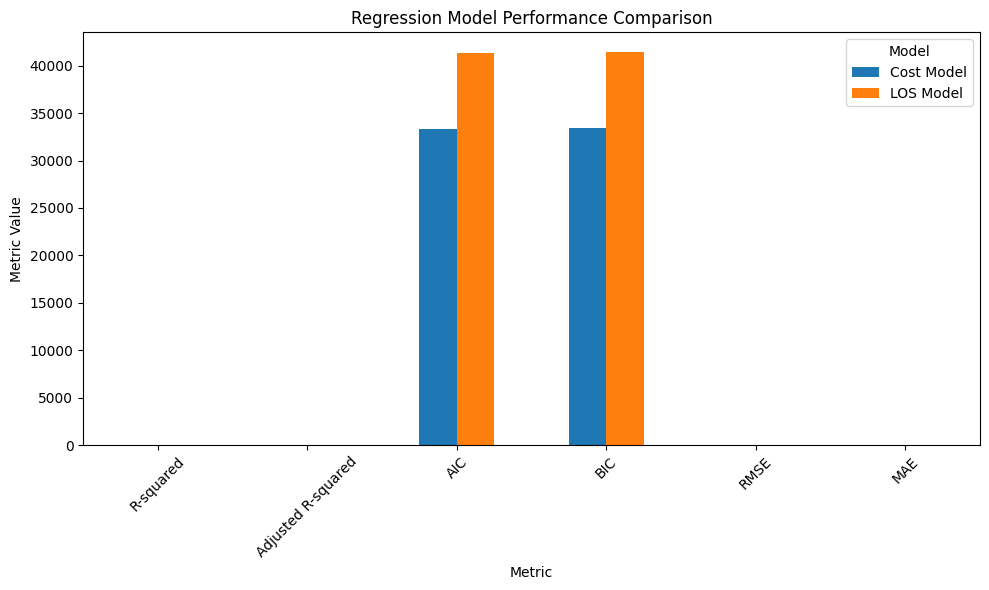

In [ ]:
import matplotlib.pyplot as plt

plot_metrics = metrics.set_index("Metric")

plot_metrics.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Regression Model Performance Comparison")
plt.ylabel("Metric Value")
plt.xticks(rotation=45)
plt.legend(title="Model")

plt.tight_layout()
plt.show()

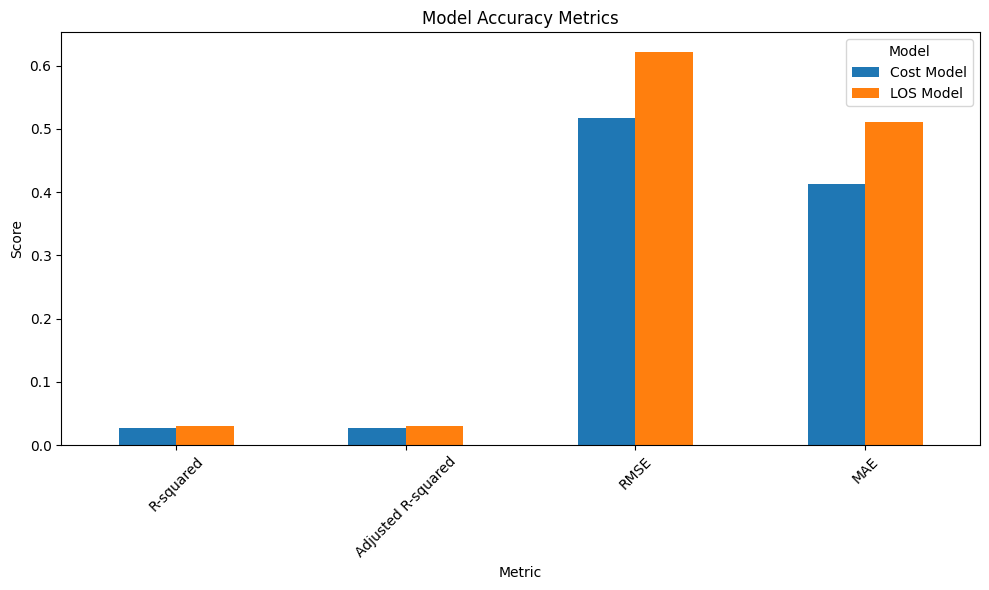

In [ ]:
accuracy_metrics = metrics[metrics["Metric"].isin([
    "R-squared",
    "Adjusted R-squared",
    "RMSE",
    "MAE"
])]

accuracy_plot = accuracy_metrics.set_index("Metric")

accuracy_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Accuracy Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(title="Model")

plt.tight_layout()
plt.show()

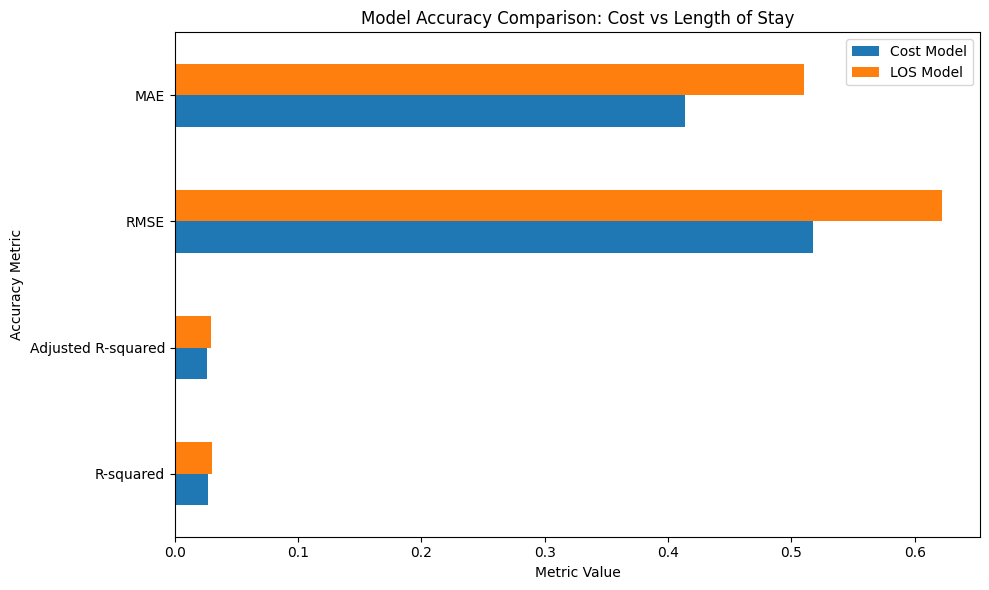

In [ ]:
accuracy_plot.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Model Accuracy Comparison: Cost vs Length of Stay")
plt.xlabel("Metric Value")
plt.ylabel("Accuracy Metric")

plt.tight_layout()
plt.show()

In [ ]:
def clean_variable_name(x):

    if "payment_typology_1" in x:
        x = x.replace("C(payment_typology_1)[T.", "")
        x = x.replace("]", "")
        return f"Payer Type: {x}"

    if "age_group" in x:
        x = x.replace("C(age_group)[T.", "")
        x = x.replace("]", "")
        return f"Age Group: {x}"

    if "gender" in x:
        x = x.replace("C(gender)[T.", "")
        x = x.replace("]", "")
        return f"Gender: {x}"

    if "race" in x:
        x = x.replace("C(race)[T.", "")
        x = x.replace("]", "")
        return f"Race: {x}"

    return x

In [ ]:
compare_coef["Factor"] = compare_coef["Variable"].apply(clean_variable_name)

compare_coef = compare_coef.drop(columns=["Variable"])

In [ ]:
compare_coef = compare_coef.rename(columns={
    "Cost_Coefficient": "Cost Impact",
    "LOS_Coefficient": "Length of Stay Impact"
})

In [ ]:
compare_coef = compare_coef.round(3)

display(
    compare_coef[
        ["Factor","Cost Impact","Length of Stay Impact"]
    ].style.hide(axis="index")
)

Factor,Cost Impact,Length of Stay Impact
Age Group: 18 to 29,-0.273000,-0.614000
Age Group: 30 to 49,-0.470000,-0.656000
Age Group: 50 to 69,-0.502000,-0.670000
Age Group: 70 or Older,-0.489000,-0.579000
Gender: M,-0.003000,-0.074000
Payer Type: Department of Corrections,0.086000,0.458000
Payer Type: Federal/State/Local/VA,-0.153000,0.041000
"Payer Type: Managed Care, Unspecified",0.198000,0.129000
Payer Type: Medicaid,0.093000,0.146000
Payer Type: Medicare,0.082000,0.124000


In [ ]:
risk_table = compare_coef.copy()

# Create text labels for Cost risk
def label_cost_risk(x):
    if x >= risk_table["Cost Impact"].quantile(0.75):
        return "Highest Risk"
    elif x >= risk_table["Cost Impact"].quantile(0.25):
        return "Moderate Risk"
    else:
        return "Lowest Risk"

# Create text labels for LOS risk
def label_los_risk(x):
    if x >= risk_table["Length of Stay Impact"].quantile(0.75):
        return "Highest Risk"
    elif x >= risk_table["Length of Stay Impact"].quantile(0.25):
        return "Moderate Risk"
    else:
        return "Lowest Risk"

risk_table["Cost Risk"] = risk_table["Cost Impact"].apply(label_cost_risk)
risk_table["LOS Risk"] = risk_table["Length of Stay Impact"].apply(label_los_risk)

display(risk_table.style.hide(axis="index"))

Cost Impact,Length of Stay Impact,Factor,Cost Risk,LOS Risk
-0.273000,-0.614000,Age Group: 18 to 29,Lowest Risk,Lowest Risk
-0.470000,-0.656000,Age Group: 30 to 49,Lowest Risk,Lowest Risk
-0.502000,-0.670000,Age Group: 50 to 69,Lowest Risk,Lowest Risk
-0.489000,-0.579000,Age Group: 70 or Older,Lowest Risk,Lowest Risk
-0.003000,-0.074000,Gender: M,Moderate Risk,Moderate Risk
0.086000,0.458000,Payer Type: Department of Corrections,Moderate Risk,Highest Risk
-0.153000,0.041000,Payer Type: Federal/State/Local/VA,Moderate Risk,Moderate Risk
0.198000,0.129000,"Payer Type: Managed Care, Unspecified",Highest Risk,Highest Risk
0.093000,0.146000,Payer Type: Medicaid,Highest Risk,Highest Risk
0.082000,0.124000,Payer Type: Medicare,Moderate Risk,Highest Risk


#Question 3: Cost Risk Table

In [ ]:
cost_risk_table = compare_coef.copy()

# Create risk labels based on Cost Impact
def label_cost_risk(x, series):
    if x >= series.quantile(0.75):
        return "Highest Risk"
    elif x >= series.quantile(0.25):
        return "Moderate Risk"
    else:
        return "Lowest Risk"

cost_risk_table["Cost Risk"] = cost_risk_table["Cost Impact"].apply(
    lambda x: label_cost_risk(x, cost_risk_table["Cost Impact"])
)

# Rename for presentation
cost_risk_table = cost_risk_table.rename(columns={
    "Factor": "Business Factor"
})

# Sort descending by highest cost risk first
cost_risk_table = cost_risk_table.sort_values("Cost Impact", ascending=False).reset_index(drop=True)

# Function to color the Cost Risk text column using Cost Impact values
def color_cost_risk(col):
    values = cost_risk_table["Cost Impact"]
    vmin = values.min()
    vmax = values.max()

    styles = []
    for val in values:
        norm = (val - vmin) / (vmax - vmin) if vmax > vmin else 0.5

        # red -> yellow -> green
        if norm >= 0.5:
            r = 255
            g = int(255 * (1 - (norm - 0.5) * 2))
            b = 0
        else:
            r = int(255 * (norm * 2))
            g = 255
            b = 0

        styles.append(f"background-color: rgb({r},{g},{b}); color: black;")
    return styles

display(
    cost_risk_table[["Business Factor", "Cost Risk"]]
    .style
    .apply(color_cost_risk, subset=["Cost Risk"])
    .hide(axis="index")
)

Business Factor,Cost Risk
"Payer Type: Managed Care, Unspecified",Highest Risk
Payer Type: Self-Pay,Highest Risk
Payer Type: Private Health Insurance,Highest Risk
Payer Type: Medicaid,Highest Risk
Payer Type: Department of Corrections,Moderate Risk
Payer Type: Medicare,Moderate Risk
Gender: M,Moderate Risk
Payer Type: Miscellaneous/Other,Moderate Risk
Race: Other Race,Moderate Risk
Race: Multi-racial,Moderate Risk


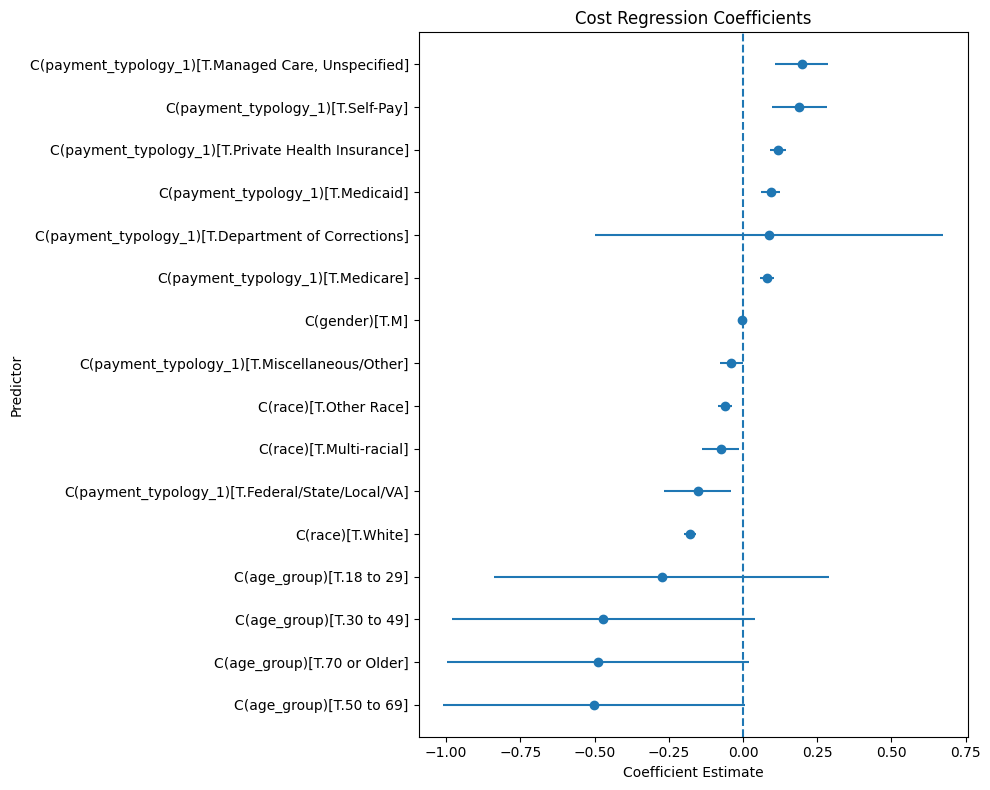

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

cost_coef = pd.DataFrame({
    "Variable": cost_model.params.index,
    "Coefficient": cost_model.params.values,
    "P_Value": cost_model.pvalues.values,
    "CI_Lower": cost_model.conf_int()[0].values,
    "CI_Upper": cost_model.conf_int()[1].values
})

cost_coef = cost_coef[cost_coef["Variable"] != "Intercept"].copy()
cost_coef = cost_coef.sort_values("Coefficient")

plt.figure(figsize=(10,8))
plt.errorbar(
    cost_coef["Coefficient"],
    cost_coef["Variable"],
    xerr=[
        cost_coef["Coefficient"] - cost_coef["CI_Lower"],
        cost_coef["CI_Upper"] - cost_coef["Coefficient"]
    ],
    fmt='o'
)

plt.axvline(x=0, linestyle='--')
plt.title("Cost Regression Coefficients")
plt.xlabel("Coefficient Estimate")
plt.ylabel("Predictor")
plt.tight_layout()
plt.show()

#Question 3: LOS Risk Table

In [ ]:
los_risk_table = compare_coef.copy()

# Create risk labels based on LOS Impact
def label_los_risk(x, series):
    if x >= series.quantile(0.75):
        return "Highest Risk"
    elif x >= series.quantile(0.25):
        return "Moderate Risk"
    else:
        return "Lowest Risk"

los_risk_table["LOS Risk"] = los_risk_table["Length of Stay Impact"].apply(
    lambda x: label_los_risk(x, los_risk_table["Length of Stay Impact"])
)

# Rename for presentation
los_risk_table = los_risk_table.rename(columns={
    "Factor": "Business Factor"
})

# Sort descending by highest LOS risk first
los_risk_table = los_risk_table.sort_values("Length of Stay Impact", ascending=False).reset_index(drop=True)

# Function to color the LOS Risk text column using LOS Impact values
def color_los_risk(col):
    values = los_risk_table["Length of Stay Impact"]
    vmin = values.min()
    vmax = values.max()

    styles = []
    for val in values:
        norm = (val - vmin) / (vmax - vmin) if vmax > vmin else 0.5

        # red -> yellow -> green
        if norm >= 0.5:
            r = 255
            g = int(255 * (1 - (norm - 0.5) * 2))
            b = 0
        else:
            r = int(255 * (norm * 2))
            g = 255
            b = 0

        styles.append(f"background-color: rgb({r},{g},{b}); color: black;")
    return styles

display(
    los_risk_table[["Business Factor", "LOS Risk"]]
    .style
    .apply(color_los_risk, subset=["LOS Risk"])
    .hide(axis="index")
)

Business Factor,LOS Risk
Payer Type: Department of Corrections,Highest Risk
Payer Type: Medicaid,Highest Risk
"Payer Type: Managed Care, Unspecified",Highest Risk
Payer Type: Medicare,Highest Risk
Payer Type: Miscellaneous/Other,Moderate Risk
Payer Type: Self-Pay,Moderate Risk
Payer Type: Federal/State/Local/VA,Moderate Risk
Payer Type: Private Health Insurance,Moderate Risk
Gender: M,Moderate Risk
Race: Multi-racial,Moderate Risk


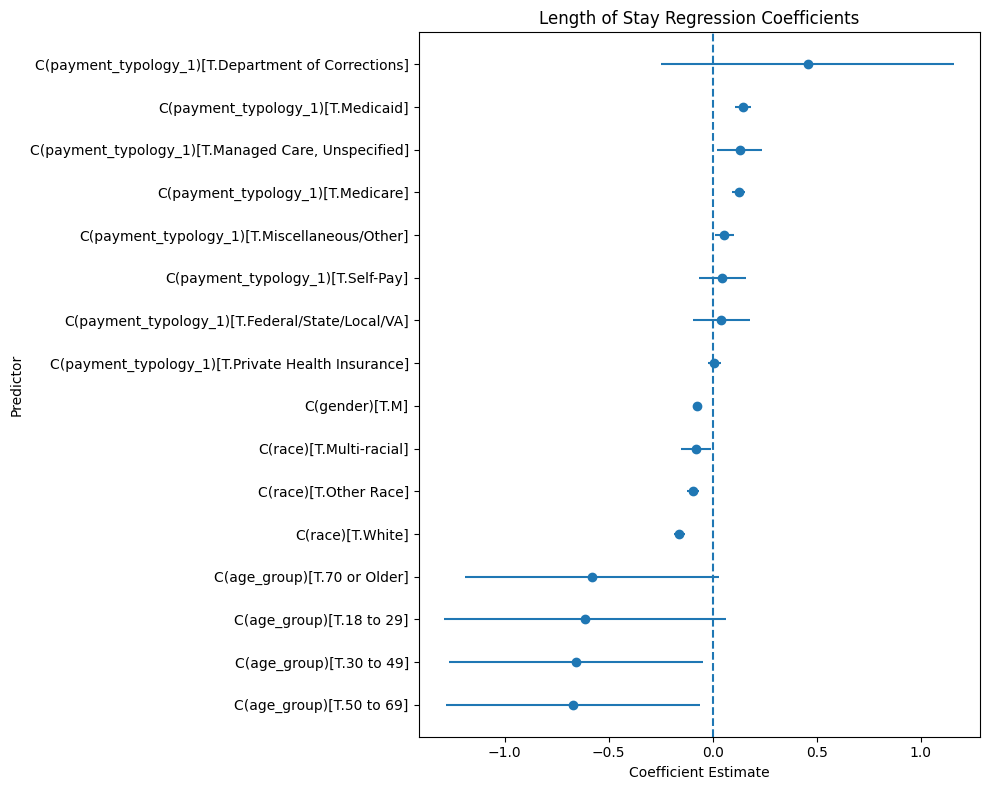

In [ ]:
los_coef = pd.DataFrame({
    "Variable": los_model.params.index,
    "Coefficient": los_model.params.values,
    "P_Value": los_model.pvalues.values,
    "CI_Lower": los_model.conf_int()[0].values,
    "CI_Upper": los_model.conf_int()[1].values
})

los_coef = los_coef[los_coef["Variable"] != "Intercept"].copy()
los_coef = los_coef.sort_values("Coefficient")

plt.figure(figsize=(10,8))
plt.errorbar(
    los_coef["Coefficient"],
    los_coef["Variable"],
    xerr=[
        los_coef["Coefficient"] - los_coef["CI_Lower"],
        los_coef["CI_Upper"] - los_coef["Coefficient"]
    ],
    fmt='o'
)

plt.axvline(x=0, linestyle='--')
plt.title("Length of Stay Regression Coefficients")
plt.xlabel("Coefficient Estimate")
plt.ylabel("Predictor")
plt.tight_layout()
plt.show()

#Question 3: Cost Chart

In [ ]:
def clean_variable_name(x):
    if "payment_typology_1" in x:
        x = x.replace("C(payment_typology_1)[T.", "").replace("]", "")
        return f"Payer Type: {x}"
    if "age_group" in x:
        x = x.replace("C(age_group)[T.", "").replace("]", "")
        return f"Age Group: {x}"
    if "gender" in x:
        x = x.replace("C(gender)[T.", "").replace("]", "")
        return f"Gender: {x}"
    if "race" in x:
        x = x.replace("C(race)[T.", "").replace("]", "")
        return f"Race: {x}"
    return x

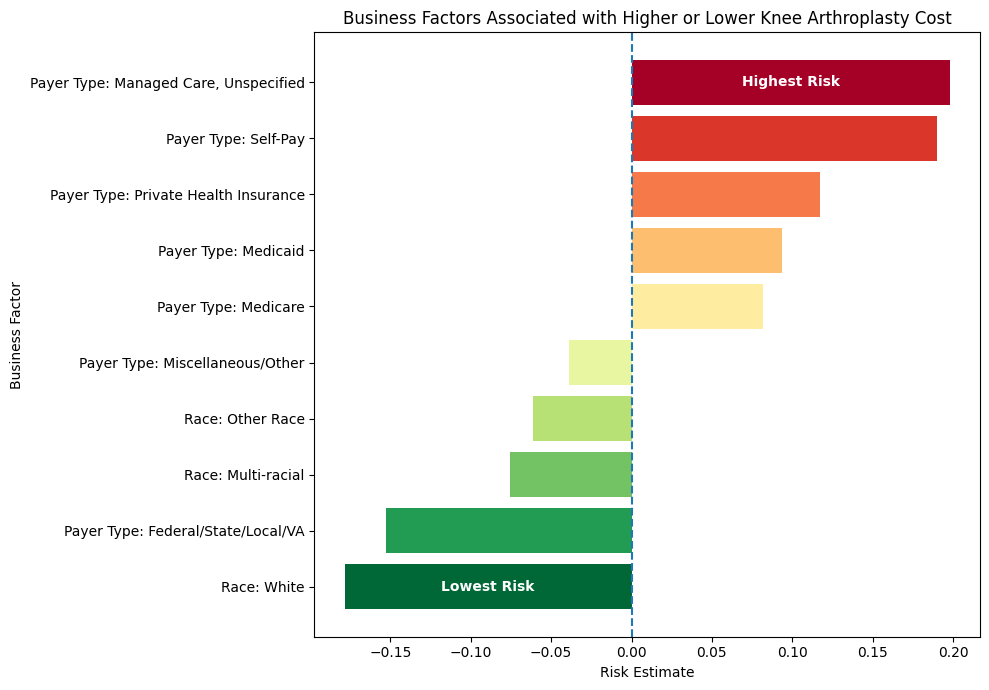

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sig_cost = cost_coef[cost_coef["P_Value"] < 0.05].copy()
sig_cost["Business Factor"] = sig_cost["Variable"].apply(clean_variable_name)
sig_cost = sig_cost.sort_values("Coefficient").reset_index(drop=True)

n = len(sig_cost)
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, n))

plt.figure(figsize=(10,7))
bars = plt.barh(sig_cost["Business Factor"], sig_cost["Coefficient"], color=colors)

plt.axvline(x=0, linestyle="--")

plt.title("Business Factors Associated with Higher or Lower Knee Arthroplasty Cost")
plt.xlabel("Risk Estimate")
plt.ylabel("Business Factor")

# Highest / Lowest risk rows
highest_idx = sig_cost["Coefficient"].idxmax()
lowest_idx = sig_cost["Coefficient"].idxmin()

for i, (coef, label) in enumerate(zip(sig_cost["Coefficient"], sig_cost["Business Factor"])):

    if i == highest_idx:
        text = "Highest Risk"
    elif i == lowest_idx:
        text = "Lowest Risk"
    else:
        text = ""

    if text:
        plt.text(
            coef * 0.5,
            i,
            text,
            color="white",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

#Question 3: LOS Risk Chart

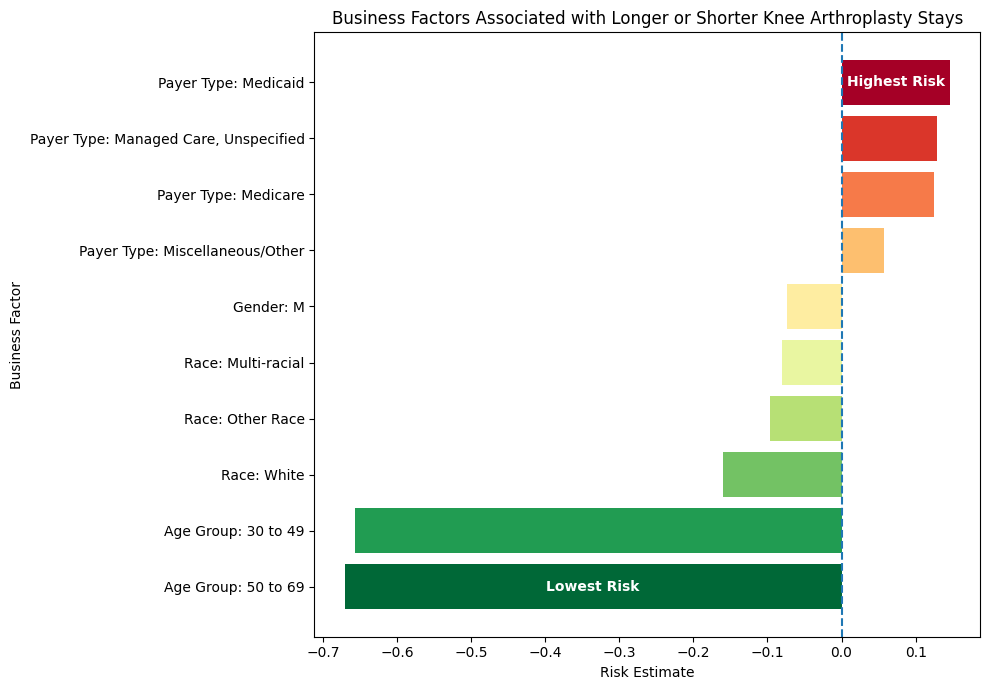

In [ ]:
sig_los = los_coef[los_coef["P_Value"] < 0.05].copy()
sig_los["Business Factor"] = sig_los["Variable"].apply(clean_variable_name)
sig_los = sig_los.sort_values("Coefficient").reset_index(drop=True)

n = len(sig_los)
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, n))

plt.figure(figsize=(10,7))
bars = plt.barh(sig_los["Business Factor"], sig_los["Coefficient"], color=colors)

plt.axvline(x=0, linestyle="--")

plt.title("Business Factors Associated with Longer or Shorter Knee Arthroplasty Stays")
plt.xlabel("Risk Estimate")
plt.ylabel("Business Factor")

highest_idx = sig_los["Coefficient"].idxmax()
lowest_idx = sig_los["Coefficient"].idxmin()

for i, (coef, label) in enumerate(zip(sig_los["Coefficient"], sig_los["Business Factor"])):

    if i == highest_idx:
        text = "Highest Risk"
    elif i == lowest_idx:
        text = "Lowest Risk"
    else:
        text = ""

    if text:
        plt.text(
            coef * 0.5,
            i,
            text,
            color="white",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

In [ ]:
compare_coef = pd.merge(
    cost_coef[["Variable", "Coefficient"]].rename(columns={"Coefficient": "Cost_Coefficient"}),
    los_coef[["Variable", "Coefficient"]].rename(columns={"Coefficient": "LOS_Coefficient"}),
    on="Variable",
    how="outer"
)

display(compare_coef.round(3))

,Variable,Cost_Coefficient,LOS_Coefficient
0,C(age_group)[T.18 to 29],-0.273,-0.614
1,C(age_group)[T.30 to 49],-0.470,-0.656
2,C(age_group)[T.50 to 69],-0.502,-0.670
3,C(age_group)[T.70 or Older],-0.489,-0.579
4,C(gender)[T.M],-0.003,-0.074
5,C(payment_typology_1)[T.Department of Correcti...,0.086,0.458
6,C(payment_typology_1)[T.Federal/State/Local/VA],-0.153,0.041
7,"C(payment_typology_1)[T.Managed Care, Unspecif...",0.198,0.129
8,C(payment_typology_1)[T.Medicaid],0.093,0.146
9,C(payment_typology_1)[T.Medicare],0.082,0.124


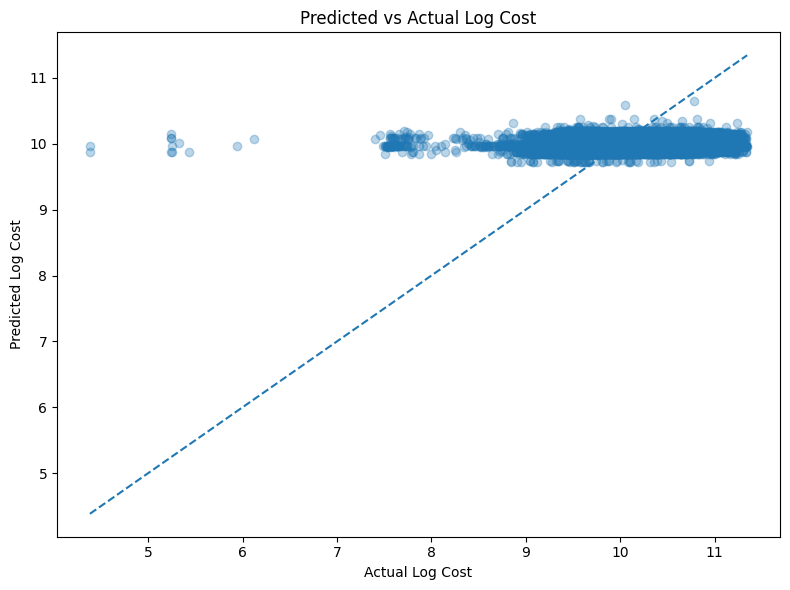

In [ ]:
model_df["predicted_log_cost"] = cost_model.fittedvalues

plt.figure(figsize=(8,6))
plt.scatter(model_df["log_cost"], model_df["predicted_log_cost"], alpha=0.3)
plt.plot(
    [model_df["log_cost"].min(), model_df["log_cost"].max()],
    [model_df["log_cost"].min(), model_df["log_cost"].max()],
    linestyle='--'
)
plt.title("Predicted vs Actual Log Cost")
plt.xlabel("Actual Log Cost")
plt.ylabel("Predicted Log Cost")
plt.tight_layout()
plt.show()

## Question 3: Are the Factors Influencing Cost and Length of Stay Similar?

### High-Level Stakeholder Interpretation

The factors influencing **cost** and **length of stay (LOS)** are **partly similar, but not identical**.

Some characteristics influence both outcomes in a consistent way. For example, **payer type**, **race**, and to some extent **age group** show statistically significant relationships with both cost and LOS. This suggests that some structural differences in the patient population and reimbursement environment influence both financial outcomes and hospital utilization.

However, the models also show important **differences**. Certain payer categories, such as **Private Health Insurance**, are associated with higher cost but do not significantly affect length of stay. Similarly, **gender does not meaningfully influence cost**, but it does have a statistically significant relationship with LOS. These differences indicate that the drivers of hospital spending are not exactly the same as the drivers of how long patients remain hospitalized.

From a business perspective, this is expected. **Length of stay reflects how long patients require inpatient care**, which is influenced by recovery needs, discharge planning, and care coordination. **Total cost reflects the intensity and mix of services delivered**, including procedures, diagnostics, and resource use. Because these outcomes capture different aspects of hospital care, some drivers overlap while others differ.

The key takeaway is that **cost management and utilization management should not be treated as identical problems**. Strategies that reduce hospital stays may not always reduce costs proportionally, and cost differences may arise even when length of stay is similar.

---

## Technical Interpretation

### Why regression was used

Regression analysis was used to determine which factors are associated with variation in **total cost** and **length of stay** while controlling for other variables. Ordinary Least Squares (OLS) regression allows each variable's relationship with the outcome to be estimated independently of the others.

Two models were estimated:

- A regression model predicting **log-transformed total cost**
- A regression model predicting **log-transformed length of stay**

Both models included the same explanatory variables:

- payer type (`payment_typology_1`)
- age group
- gender
- race

Using the same predictors across both models allows a direct comparison of which variables influence each outcome.

### Why log transformations were used

Both **hospital cost** and **length of stay** tend to be right-skewed in healthcare data. Most patients have moderate costs and hospital stays, while a smaller number experience extremely expensive or prolonged hospitalizations.

To address this skewness, the dependent variables were transformed using the natural logarithm:

- `log_cost`
- `log_los`

Log transformation helps stabilize variance, reduces the influence of extreme values, and produces more reliable regression estimates.

### Why categorical variables were used

The regression formula used `C(...)` to treat variables as categorical. This is important because variables such as payer type, race, and gender represent **groups rather than numeric values**. Treating them as categorical variables allows the model to estimate the effect of each category relative to a reference group.

### What the results show technically

The two models produce **similar but not identical patterns of significance and effect size**.

#### Similar factors

Several variables are statistically significant in both models:

- **Medicaid and Medicare** are associated with higher cost and longer length of stay relative to the reference payer group.
- Several **race categories** show consistent negative coefficients across both models.
- Some **age groups** show relationships with both outcomes.

These similarities indicate that certain patient demographic characteristics and payer categories influence both financial outcomes and hospital utilization.

#### Different factors

However, the models also reveal clear differences:

- **Private Health Insurance** is a significant predictor of higher cost but does not significantly affect length of stay.
- **Gender** is not a significant predictor of cost but is statistically significant for LOS, with male patients showing shorter predicted stays relative to the reference category.
- Some **age effects** are stronger for LOS than for cost.

These differences highlight that cost and LOS are related but distinct measures of hospital performance.

### Model explanatory power

Both models have relatively low explanatory power:

- **Cost model R² ≈ 0.027**
- **LOS model R² ≈ 0.030**

This means the included variables explain only a small portion of the variation in cost and LOS. This is typical in healthcare utilization analysis, where outcomes are influenced by many additional factors not included in the model, such as clinical severity, complications, hospital practices, surgical technique, and discharge destination.

### Technical conclusion

The regression results demonstrate that **cost and length of stay share some common drivers but are not determined by exactly the same factors**. While patient demographics and payer type contribute to both outcomes, differences in significance and effect size suggest that financial outcomes and utilization outcomes capture different aspects of inpatient care.

For healthcare organizations, this implies that improving operational efficiency and managing financial performance may require **different interventions and policy strategies** rather than a single unified approach.

Sources:

https://journals.plos.org/plosone/article?id=10.1371%2Fjournal.pone.0288239&utm

https://onlinelibrary.wiley.com/doi/full/10.1002/hec.1653?utm

In [ ]:
analytic_trim[["total_costs","length_of_stay"]].corr()

,total_costs,length_of_stay
total_costs,1.000000,0.502357
length_of_stay,0.502357,1.000000


| Variable           | Avg Cost per Case | Avg Length of Stay |
| ------------------ | ----------------- | ------------------ |
| Avg Cost per Case  | 1.00              | 0.50               |
| Avg Length of Stay | 0.50              | 1.00               |


In [ ]:
import pandas as pd

# Merge cost and LOS coefficients
compare_coef = pd.merge(
    cost_coef[["Variable","Coefficient"]].rename(columns={"Coefficient":"Cost Impact"}),
    los_coef[["Variable","Coefficient"]].rename(columns={"Coefficient":"LOS Impact"}),
    on="Variable",
    how="inner"
)

# Keep significant predictors in either model
sig_cost = cost_coef[cost_coef["P_Value"] < 0.05]["Variable"]
sig_los = los_coef[los_coef["P_Value"] < 0.05]["Variable"]

compare_coef = compare_coef[
    compare_coef["Variable"].isin(set(sig_cost).union(set(sig_los)))
]

# Clean variable names
compare_coef["Business Factor"] = compare_coef["Variable"].apply(clean_variable_name)

compare_coef = compare_coef.drop(columns="Variable")

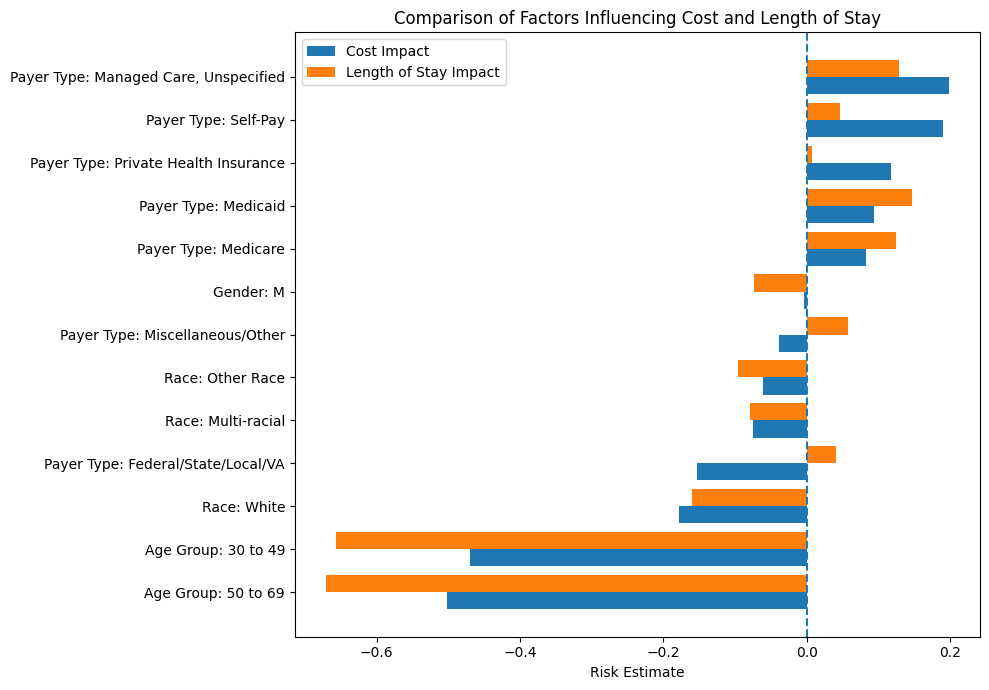

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

compare_coef = compare_coef.sort_values("Cost Impact")

y = np.arange(len(compare_coef))

plt.figure(figsize=(10,7))

plt.barh(
    y - 0.2,
    compare_coef["Cost Impact"],
    height=0.4,
    label="Cost Impact"
)

plt.barh(
    y + 0.2,
    compare_coef["LOS Impact"],
    height=0.4,
    label="Length of Stay Impact"
)

plt.yticks(y, compare_coef["Business Factor"])

plt.axvline(x=0, linestyle="--")

plt.xlabel("Risk Estimate")
plt.title("Comparison of Factors Influencing Cost and Length of Stay")

plt.legend()

plt.tight_layout()
plt.show()

#Question 4: Business Importance and Interpretation

## Business Interpretation

Understanding variation in cost and length of stay for knee arthroplasty patients provides important insights for healthcare organizations.

Differences in cost by payer type may reflect reimbursement policies, case mix, or differences in patient complexity.

Length of stay differences may reflect variations in hospital care pathways, discharge planning, or patient health status.

Examining payer mix across hospital service areas also helps organizations understand regional market dynamics and payer distribution.

These insights can support strategic decisions related to contracting, pricing, operational efficiency, and care management.

## Identifying Knee Arthroplasty Patients

The business case asks us to determine the best way to identify patients who underwent knee arthroplasty. Because the SPARCS dataset is de-identified, procedure codes such as CPT or ICD procedure codes are not directly available in the public dataset. Instead, the dataset provides descriptive clinical groupings that can be used to approximate procedure identification.

Two fields are particularly useful for identifying knee arthroplasty cases:

- **CCSR Procedure Description**  
  This variable groups procedures into clinically meaningful categories. Searching this field for terms such as *knee*, *arthroplasty*, or *replacement* allows us to identify records associated with knee replacement procedures.

- **CCSR Procedure Code (MST006)**  
  This CCSR code above has a 1:1 correlation to the *CCSR Procedure Description* for "Knee Arthoplasty". The CCSR Procedure Code this is the most granular, explicitly labeled coding system because it is a clinically significant coding system, compared to ARP which is mostly focus on claims and inpatient reimbursement.
  
Using these two variables together provides a reasonable approach for identifying knee arthroplasty patients within the SPARCS dataset. Records that contain both **knee** and either **arthroplasty** or **replacement** in these descriptive fields will be used to define the knee arthroplasty cohort for the analysis.

This approach allows us to approximate the relevant surgical population while working within the constraints of a de-identified public health dataset.